In [ ]:
#Import libraries that we are going to use on this model
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#This dataset don't require a cleaning process]
#Dataset from https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
df = pd.read_csv("/content/heart.csv")
df.head(10)
# target => 0 is for heatlh and 1 is for disease and 2 for unknown
# I am not a profissional on heatlh area

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [ ]:
#Train split test

from sklearn.model_selection import train_test_split

x = df.drop('target', axis=1)
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=43)

x_train.shape

(615, 13)

In [ ]:
#Scale - insensitive / Time to see the best model

from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier()
forest.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(x_train, y_train)

GaussianNB()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(x_train, y_train)

GradientBoostingClassifier()

In [ ]:
#Scale-Sensitive models
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(x_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
#Logistic Regression is a classification model

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)

LogisticRegression()

In [ ]:
from sklearn.svm import SVC

svm = SVC()
svm.fit(x_train_scaled, y_train)

SVC()

In [ ]:
# Acurracy's score => how offen the prediction is right
print(forest.score(x_test, y_test))
print(nb.score(x_test, y_test))
print(gb.score(x_test, y_test))
print(knn.score(x_test_scaled, y_test))
print(lr.score(x_test_scaled, y_test))
print(svm.score(x_test_scaled, y_test))

0.9926829268292683
0.8097560975609757
0.9512195121951219
0.8853658536585366
0.875609756097561
0.9243902439024391


In [ ]:
# In this project we are going to focus on recalls because i am not a profissional on the area and
# For me the problem is someone has heart disease and is not detect
from sklearn.metrics import recall_score

f_predict = forest.predict(x_test)
print("Forest model predict:",recall_score(y_test,f_predict))

nb_predict = nb.predict(x_test)
print("Naive Bayes model predict:",recall_score(y_test,nb_predict))

gb_predict = gb.predict(x_test)
print("Gradient Boosting model predict:",recall_score(y_test,gb_predict))

knn_predict = knn.predict(x_test_scaled)
print("KNN model predict:",recall_score(y_test,knn_predict))

lr_predict = lr.predict(x_test_scaled)
print("Logistic Regression model predict:",recall_score(y_test,lr_predict))

svm_predict = svm.predict(x_test_scaled)
print("SVM model predict:",recall_score(y_test,svm_predict))

Forest model predict: 0.9866666666666667
Naive Bayes model predict: 0.8533333333333334
Gradient Boosting model predict: 0.9466666666666667
KNN model predict: 0.8977777777777778
Logistic Regression model predict: 0.9066666666666666
SVM model predict: 0.9155555555555556


<Axes: >

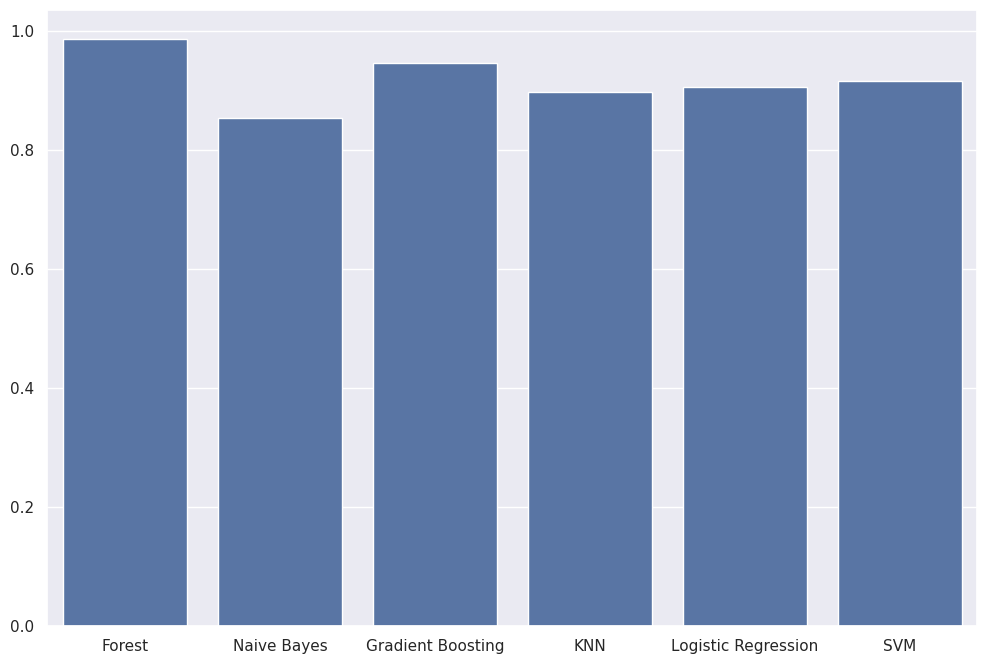

In [ ]:
#Plot results with sns => cross validation not the "real meaning"
sns.set_theme(style="whitegrid")
sns.set(rc={'figure.figsize':(12,8)})
x_labels = ['Forest', 'Naive Bayes', 'Gradient Boosting', 'KNN', 'Logistic Regression', 'SVM']
y_labels = [recall_score(y_test,f_predict), recall_score(y_test,nb_predict), recall_score(y_test,gb_predict), recall_score(y_test,knn_predict), recall_score(y_test,lr_predict), recall_score(y_test,svm_predict)]
sns.barplot(x=x_labels, y=y_labels)

0.9984144144144145


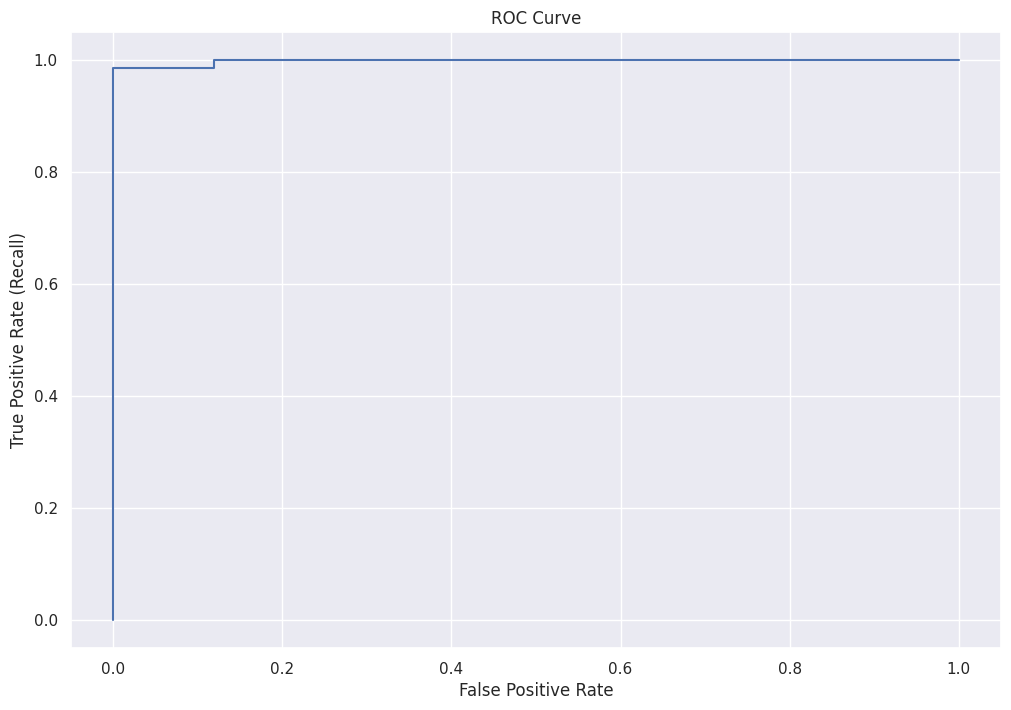

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

y_probability = forest.predict_proba(x_test)
#[:,1] => roc_curve is 2d
#fpr => false positive rate , trp => true positive rate
fpr , trp , thresholds = roc_curve(y_test , y_probability[:,1])
print(roc_auc_score(y_test,y_probability[:,1]))

plt.plot(fpr,trp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.show()

0.9924804804804805


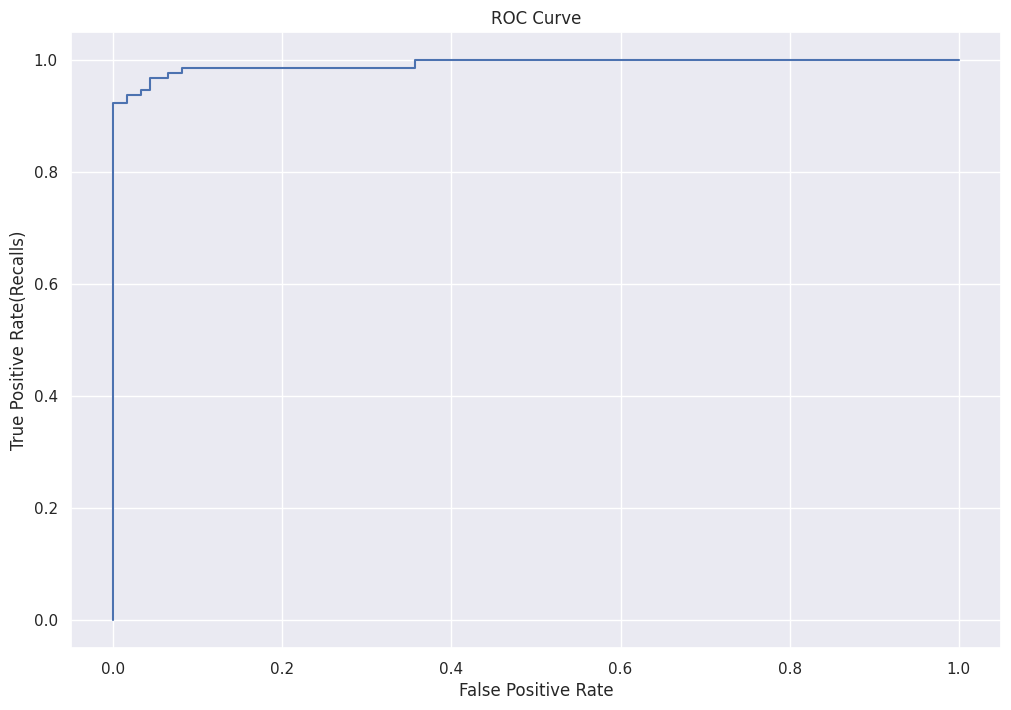

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

y_probability = gb.predict_proba(x_test)
#[:,1] => roc_curve is 2d
#fpr => false positive rate , trp => true positive rate
fpr , trp , thresholds = roc_curve(y_test , y_probability[:,1])
print(roc_auc_score(y_test,y_probability[:,1]))

plt.plot(fpr,trp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate(Recalls)")
plt.title("ROC Curve")
plt.show()

0.9011891891891891


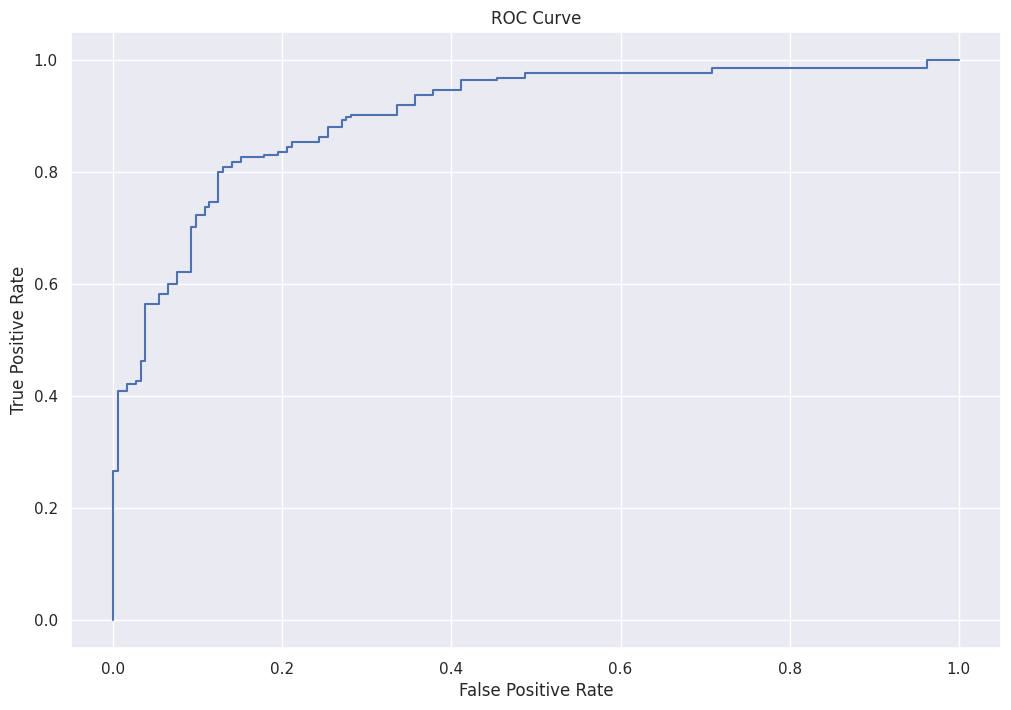

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

y_probability = nb.predict_proba(x_test)
#[:,1] => roc_curve is 2d
#fpr => false positive rate , trp => true positive rate
fpr , trp , thresholds = roc_curve(y_test , y_probability[:,1])
print(roc_auc_score(y_test,y_probability[:,1]))

plt.plot(fpr,trp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.7641561561561561


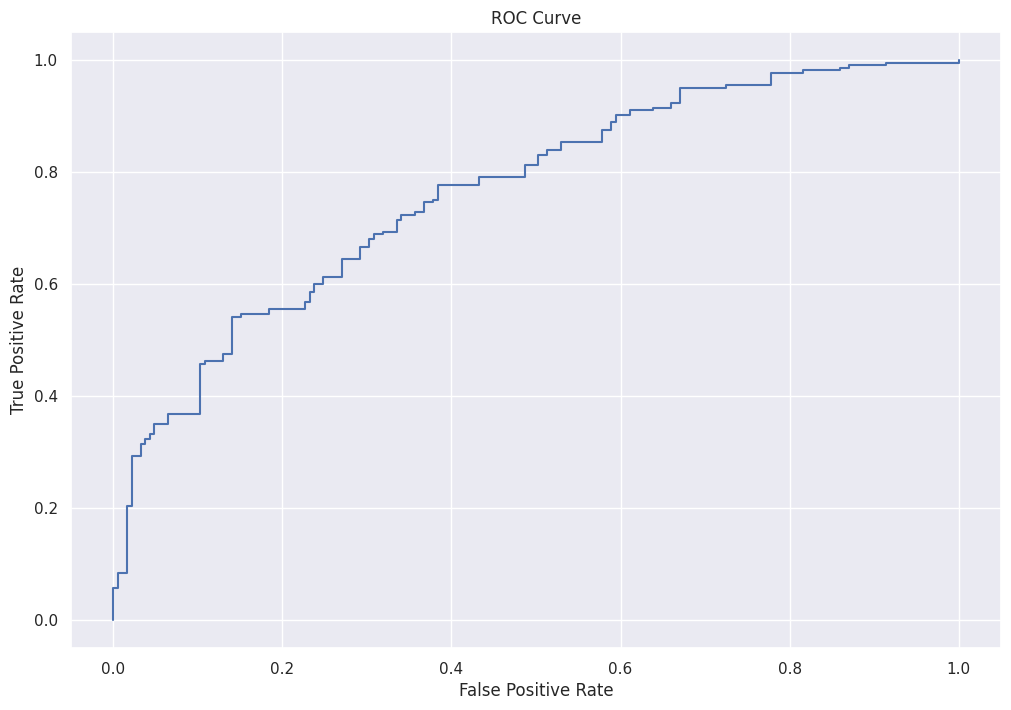

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

y_probability = lr.predict_proba(x_test)
#[:,1] => roc_curve is 2d
#fpr => false positive rate , trp => true positive rate
fpr , trp , thresholds = roc_curve(y_test , y_probability[:,1])
print(roc_auc_score(y_test,y_probability[:,1]))

plt.plot(fpr,trp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


0.5493213213213214


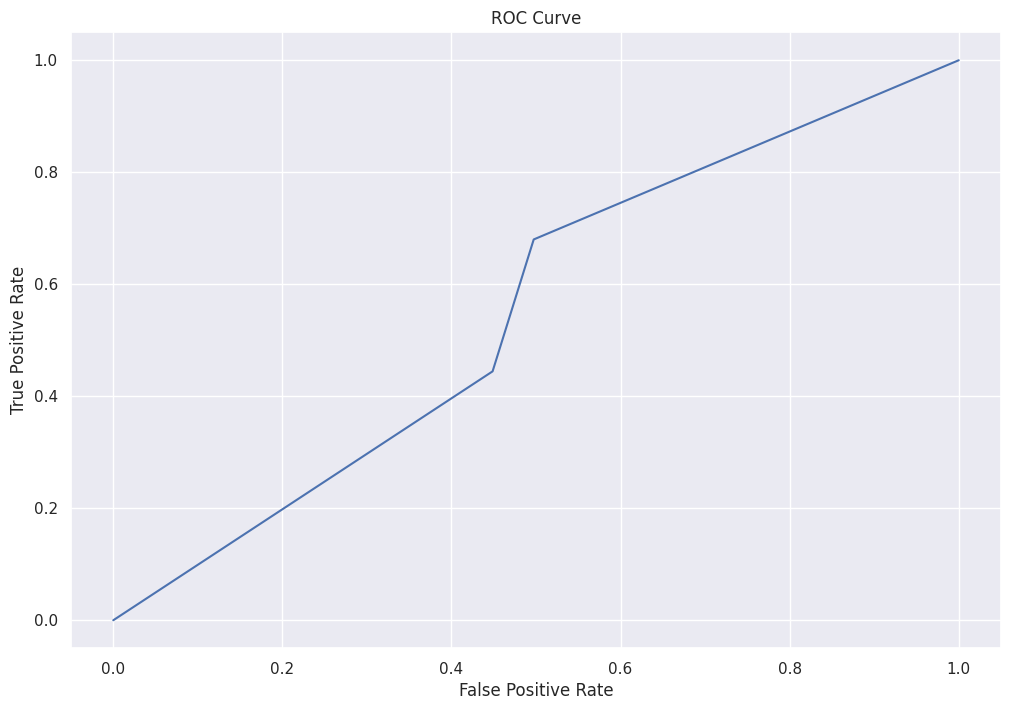

In [ ]:
from sklearn.metrics import roc_curve,roc_auc_score

y_probability = knn.predict_proba(x_test)
#[:,1] => roc_curve is 2d
#fpr => false positive rate , trp => true positive rate
fpr , trp , thresholds = roc_curve(y_test , y_probability[:,1])
print(roc_auc_score(y_test,y_probability[:,1]))

plt.plot(fpr,trp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
#Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2',None]
}
#All CPU's cores = n_jobs=-1
forest_hyper = RandomForestClassifier(n_jobs=-1,random_state=43)
#cv = crossv => split data in 3 and see which one is better for training
grid_search = GridSearchCV(forest_hyper,param_grid,cv=3,n_jobs=-1)
grid_search.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(n_jobs=-1, random_state=43),
             n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2', None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]})

In [ ]:
best_forest = grid_search.best_estimator_
best_forest

RandomForestClassifier(max_depth=10, n_estimators=300, n_jobs=-1,
                       random_state=43)

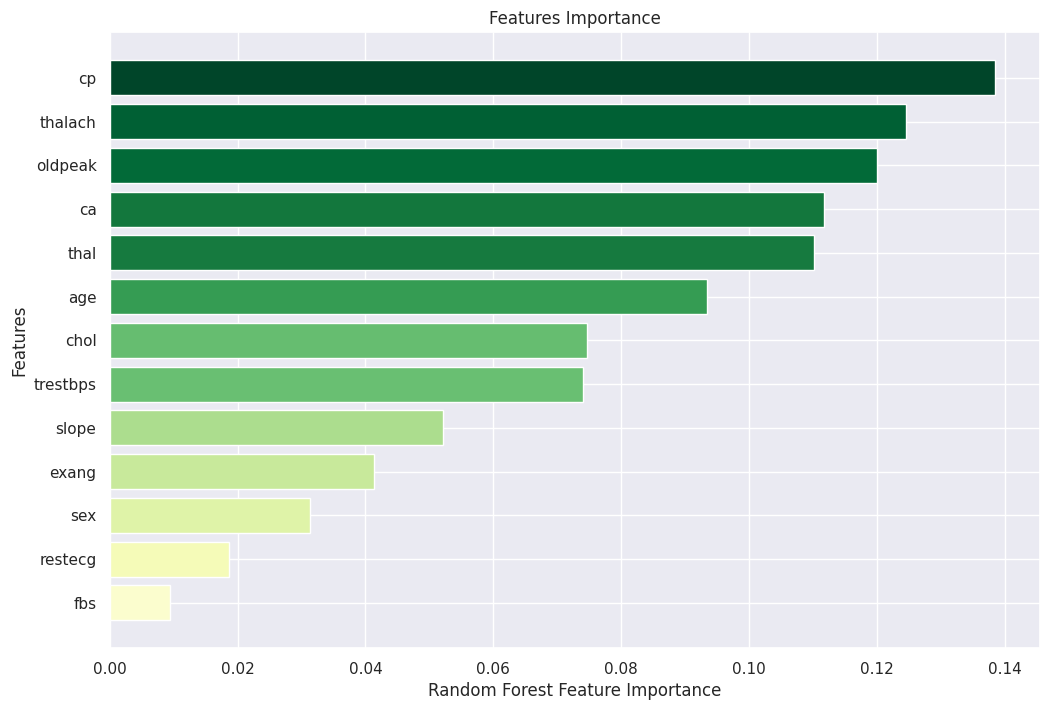

In [ ]:
#Features importance => which features are more important than others features
feature_importances = best_forest.feature_importances_
features_names = best_forest.feature_names_in_

sorted_indices = np.argsort(feature_importances)
sorted_feature_importances = feature_importances[sorted_indices]
sorted_features_names = features_names[sorted_indices]

clrs = plt.cm.YlGn(sorted_feature_importances/max(sorted_feature_importances))

plt.barh(sorted_features_names,sorted_feature_importances,color=clrs)
plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Features")
plt.title("Features Importance")
plt.show()

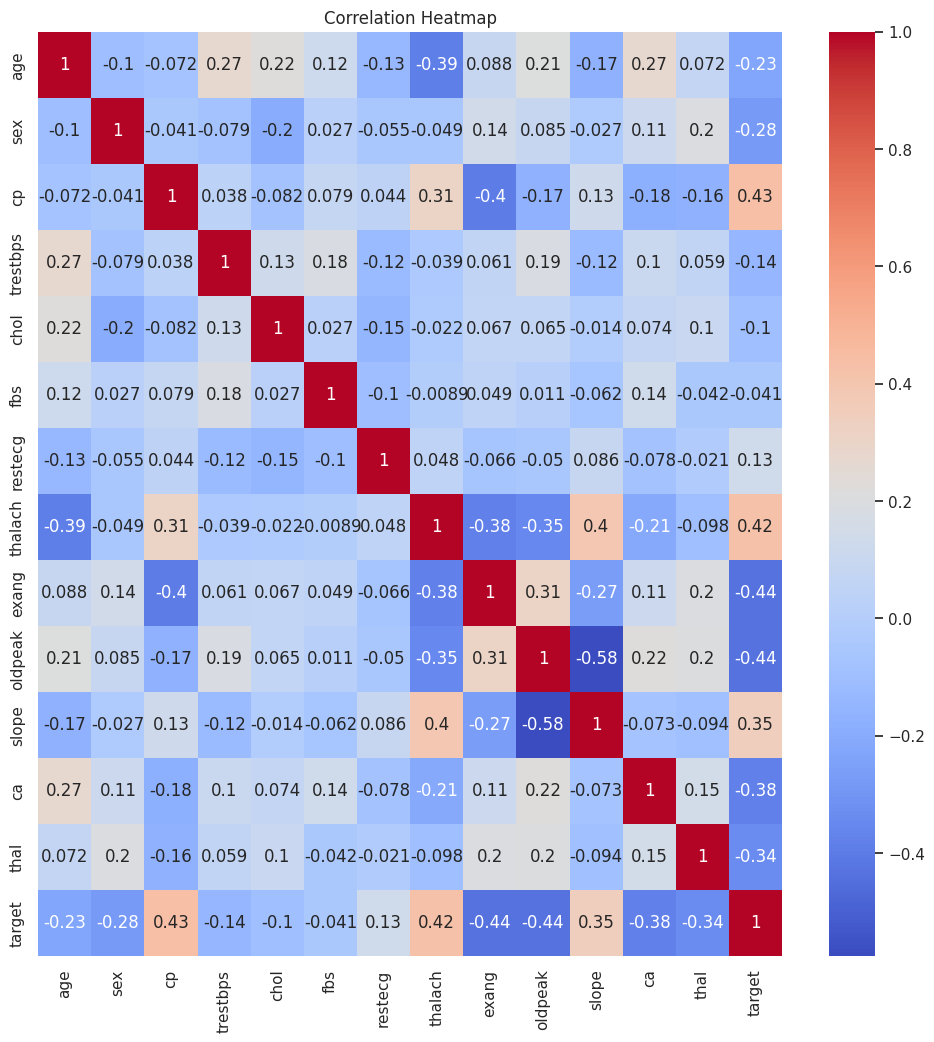

In [ ]:
#Correlation features in heatmap // target's magnitude // a strong corr doesn't mean that is for a decision making when it comes to classify if someone has a heart disease or not
corr = df.corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# negative corr => "reverse correlation"

0.9926829268292683


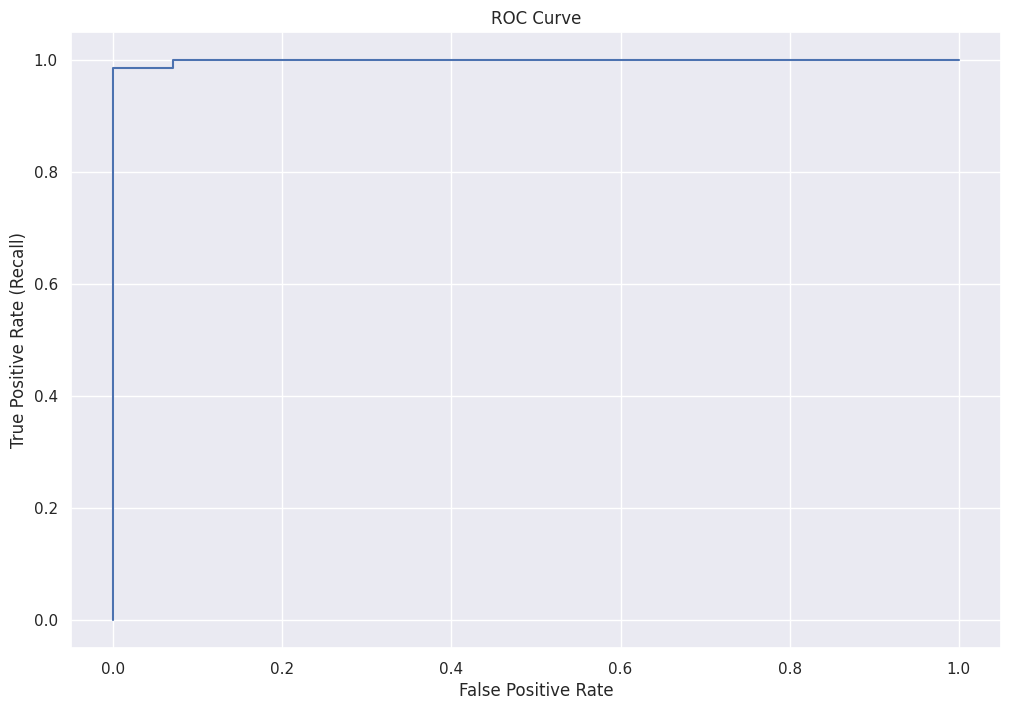

In [ ]:
print(best_forest.score(x_test,y_test))
from sklearn.metrics import roc_curve,roc_auc_score

y_probability = best_forest.predict_proba(x_test)
fpr , trp , thresholds = roc_curve(y_test , y_probability[:,1])

plt.plot(fpr,trp)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.show()

In [ ]:
best_f_predict = best_forest.predict(x_test)
print("Best forest model predict:",recall_score(y_test,best_f_predict))


#If you wanna to predict someone if they have heart disease only create a new info the best_forest in predict or predict_proba

Best forest model predict: 0.9866666666666667
